## Problema e pergunta central

**Problema:** Os municípios cearenses apresentam trajetórias distintas de transformação agropecuária ao longo das últimas duas décadas, tanto em sua composição produtiva quanto na importância da agropecuária para a economia local.

**Pergunta central:** Como o perfil agropecuário dos municípios cearenses se transformou entre 2003 e 2024 e como essas mudanças se relacionam com sua estrutura econômica?

Este notebook cobre a parte de **estrutura econômica**: PIB, VAB e participação da agropecuária, por município e ao longo do tempo — inclusive como essa participação mudou entre 2003 e o último ano disponível (2021, ver tratamento de símbolo especial).

## 1. Carga dos dados

### Dicionário de dados

| Coluna | Significado |
|---|---|
| `nivel_territorial_codigo` / `nivel_territorial_nome` | Nível geográfico: N1 Brasil, N3 Ceará, N6 Município |
| `territorio_codigo` | Código IBGE do território (1=Brasil, 23=Ceará, 7 dígitos para município) |
| `territorio_nome` | Nome do território |
| `ano_codigo` | Ano de referência (2003-2023) |
| `variavel_codigo` / `variavel_nome` | Qual grandeza: PIB, VAB total, VAB agropecuária, participação % agro |
| `unidade` | Mil Reais (para valores monetários) ou % (para participação) |
| `valor` | Valor da variável |

Fonte: IBGE/SIDRA, tabela 5938. Ceará + 184 municípios + Brasil, 2003-2023.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

AZUL = "#0B5FA5"
LARANJA = "#F28E2B"

In [2]:
pib_path = "../dados/raw/dados_originais/t5938_pib_agropecuaria_2003_2023_ce_br.csv"

In [3]:
df = pd.read_csv(
    pib_path,
    sep=";", encoding="utf-8-sig"
)
df.shape
df.head(10)

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,valor
0,N1,Brasil,1,Brasil,2003,2003,37,Produto Interno Bruto a preços correntes,Mil Reais,1717950386
1,N1,Brasil,1,Brasil,2004,2004,37,Produto Interno Bruto a preços correntes,Mil Reais,1957751224
2,N1,Brasil,1,Brasil,2005,2005,37,Produto Interno Bruto a preços correntes,Mil Reais,2170584503
3,N1,Brasil,1,Brasil,2006,2006,37,Produto Interno Bruto a preços correntes,Mil Reais,2409449916
4,N1,Brasil,1,Brasil,2007,2007,37,Produto Interno Bruto a preços correntes,Mil Reais,2720262951
5,N1,Brasil,1,Brasil,2008,2008,37,Produto Interno Bruto a preços correntes,Mil Reais,3109803097
6,N1,Brasil,1,Brasil,2009,2009,37,Produto Interno Bruto a preços correntes,Mil Reais,3333039339
7,N1,Brasil,1,Brasil,2010,2010,37,Produto Interno Bruto a preços correntes,Mil Reais,3885847000
8,N1,Brasil,1,Brasil,2011,2011,37,Produto Interno Bruto a preços correntes,Mil Reais,4376382000
9,N1,Brasil,1,Brasil,2012,2012,37,Produto Interno Bruto a preços correntes,Mil Reais,4814760000


## 2. Estrutura e inspeção inicial

In [4]:
df.dtypes

nivel_territorial_codigo    object
nivel_territorial_nome      object
territorio_codigo            int64
territorio_nome             object
ano_codigo                   int64
ano_nome                     int64
variavel_codigo              int64
variavel_nome               object
unidade                     object
valor                       object
dtype: object

In [5]:
df["nivel_territorial_nome"].value_counts()

nivel_territorial_nome
Município               15456
Brasil                     84
Unidade da Federação       84
Name: count, dtype: int64

In [6]:
df["variavel_nome"].value_counts()

variavel_nome
Produto Interno Bruto a preços correntes                                                                                        3906
Valor adicionado bruto a preços correntes total                                                                                 3906
Valor adicionado bruto a preços correntes da agropecuária                                                                       3906
Participação do valor adicionado bruto a preços correntes da agropecuária no valor adicionado bruto a preços correntes total    3906
Name: count, dtype: int64

In [7]:
df["ano_codigo"].agg(["min","max"])

min    2003
max    2023
Name: ano_codigo, dtype: int64

In [8]:
df["valor"].isna().sum()

np.int64(0)

## 3. Limpeza de dados

(o split abaixo é só preliminar, pra inspecionar Brasil/Ceará/Município separado antes de limpar — refeito no final da seção depois que `valor` for tratado)

**separação de datasets**

In [9]:
df_brasil = df[df["nivel_territorial_nome"]=="Brasil"]
df_ce = df[df["nivel_territorial_nome"]=="Unidade da Federação"]
df_mun = df[df["nivel_territorial_nome"]=="Município"]

In [10]:
print(df["nivel_territorial_codigo"].unique())
print(df["nivel_territorial_nome"].unique())
print(df["territorio_codigo"].unique())
print(df["territorio_nome"].unique())
print(df["ano_codigo"].unique())
print(df["ano_nome"].unique())
print(df["variavel_codigo"].unique())
print(df["variavel_nome"].unique())
print(df["unidade"].unique())
print(df["valor"].unique())

['N1' 'N3' 'N6']
['Brasil' 'Unidade da Federação' 'Município']
[      1      23 2300101 2300150 2300200 2300309 2300408 2300507 2300606
 2300705 2300754 2300804 2300903 2301000 2301109 2301208 2301257 2301307
 2301406 2301505 2301604 2301703 2301802 2301851 2301901 2301950 2302008
 2302057 2302107 2302206 2302305 2302404 2302503 2302602 2302701 2302800
 2302909 2303006 2303105 2303204 2303303 2303402 2303501 2303600 2303659
 2303709 2303808 2303907 2303931 2303956 2304004 2304103 2304202 2304236
 2304251 2304269 2304277 2304285 2304301 2304350 2304400 2304459 2304509
 2304608 2304657 2304707 2304806 2304905 2304954 2305001 2305100 2305209
 2305233 2305266 2305308 2305332 2305357 2305407 2305506 2305605 2305654
 2305704 2305803 2305902 2306009 2306108 2306207 2306256 2306306 2306405
 2306504 2306553 2306603 2306702 2306801 2306900 2307007 2307106 2307205
 2307254 2307304 2307403 2307502 2307601 2307635 2307650 2307700 2307809
 2307908 2308005 2308104 2308203 2308302 2308351 2308377 2308

In [11]:
df_brasil.head()

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,valor
0,N1,Brasil,1,Brasil,2003,2003,37,Produto Interno Bruto a preços correntes,Mil Reais,1717950386
1,N1,Brasil,1,Brasil,2004,2004,37,Produto Interno Bruto a preços correntes,Mil Reais,1957751224
2,N1,Brasil,1,Brasil,2005,2005,37,Produto Interno Bruto a preços correntes,Mil Reais,2170584503
3,N1,Brasil,1,Brasil,2006,2006,37,Produto Interno Bruto a preços correntes,Mil Reais,2409449916
4,N1,Brasil,1,Brasil,2007,2007,37,Produto Interno Bruto a preços correntes,Mil Reais,2720262951


In [12]:
df_ce.head()

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,valor
21,N3,Unidade da Federação,23,Ceará,2003,2003,37,Produto Interno Bruto a preços correntes,Mil Reais,32687418
22,N3,Unidade da Federação,23,Ceará,2004,2004,37,Produto Interno Bruto a preços correntes,Mil Reais,36890816
23,N3,Unidade da Federação,23,Ceará,2005,2005,37,Produto Interno Bruto a preços correntes,Mil Reais,41059459
24,N3,Unidade da Federação,23,Ceará,2006,2006,37,Produto Interno Bruto a preços correntes,Mil Reais,46500321
25,N3,Unidade da Federação,23,Ceará,2007,2007,37,Produto Interno Bruto a preços correntes,Mil Reais,50818749


In [13]:
df_mun.head()

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,valor
42,N6,Município,2300101,Abaiara - CE,2003,2003,37,Produto Interno Bruto a preços correntes,Mil Reais,17657
43,N6,Município,2300101,Abaiara - CE,2004,2004,37,Produto Interno Bruto a preços correntes,Mil Reais,16808
44,N6,Município,2300101,Abaiara - CE,2005,2005,37,Produto Interno Bruto a preços correntes,Mil Reais,17153
45,N6,Município,2300101,Abaiara - CE,2006,2006,37,Produto Interno Bruto a preços correntes,Mil Reais,22869
46,N6,Município,2300101,Abaiara - CE,2007,2007,37,Produto Interno Bruto a preços correntes,Mil Reais,25383


**Símbolo especial SIDRA**

In [14]:
pd.to_numeric(df["valor"], errors="coerce").isna().sum()

np.int64(1116)

**tratamento de símbolo especial SIDRA**

`valor` tem 1116 linhas com `"..."` (dado não disponível na fonte), concentradas em 2022 e 2023, apenas nas variáveis derivadas (VAB total, VAB agropecuária, participação %) — o PIB bruto (variável 37) está completo em todos os anos. É atraso de divulgação do IBGE (VAB municipal sai depois do PIB), não erro de coleta.

Decisão: converter para `NaN` (não interpolar, não zerar). Análises que envolvam VAB/participação em 2022-2023 devem considerar essa lacuna.

In [15]:
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["valor"].isna().sum()

np.int64(1116)

In [16]:
# refaz os recortes: df_brasil/df_ce/df_mun foram criados ANTES da conversão de valor,
# então ainda estão com "valor" como object. reexecuta pra ficarem consistentes.
df_brasil = df[df["nivel_territorial_nome"]=="Brasil"]
df_ce = df[df["nivel_territorial_nome"]=="Unidade da Federação"]
df_mun = df[df["nivel_territorial_nome"]=="Município"]

df.groupby(["ano_codigo","variavel_nome"])["valor"].apply(lambda s: s.isna().sum()).loc[lambda s: s>0]

ano_codigo  variavel_nome                                                                                                               
2022        Participação do valor adicionado bruto a preços correntes da agropecuária no valor adicionado bruto a preços correntes total    186
            Valor adicionado bruto a preços correntes da agropecuária                                                                       186
            Valor adicionado bruto a preços correntes total                                                                                 186
2023        Participação do valor adicionado bruto a preços correntes da agropecuária no valor adicionado bruto a preços correntes total    186
            Valor adicionado bruto a preços correntes da agropecuária                                                                       186
            Valor adicionado bruto a preços correntes total                                                                                 186

**Chave primária e duplicatas**

`territorio_codigo` + `ano_codigo` + `variavel_nome` (não fizemos essa conferência ainda no PIB — fizemos no PAM e PPM, faltava aqui).

In [17]:
chave = ["territorio_codigo", "ano_codigo", "variavel_nome"]
df.duplicated(subset=chave).sum()

np.int64(0)

**Nome do território e coluna redundante**

- `territorio_nome` tem sufixo `" - CE"` só nos municípios (Brasil e Ceará não têm) — tira o sufixo pra ficar consistente.
- `ano_nome` é idêntico a `ano_codigo` (redundante) — confere e descarta.

In [18]:
df["territorio_nome"] = df["territorio_nome"].str.replace(r" - CE$", "", regex=True)

(df["ano_codigo"] != df["ano_nome"]).sum()

np.int64(0)

In [19]:
df = df.drop(columns=["ano_nome"])

df_brasil = df[df["nivel_territorial_nome"]=="Brasil"]
df_ce = df[df["nivel_territorial_nome"]=="Unidade da Federação"]
df_mun = df[df["nivel_territorial_nome"]=="Município"]

## 4. Exploração (matplotlib)

**1. PIB Ceará 2003-2023**

max: 2023, min: 2003


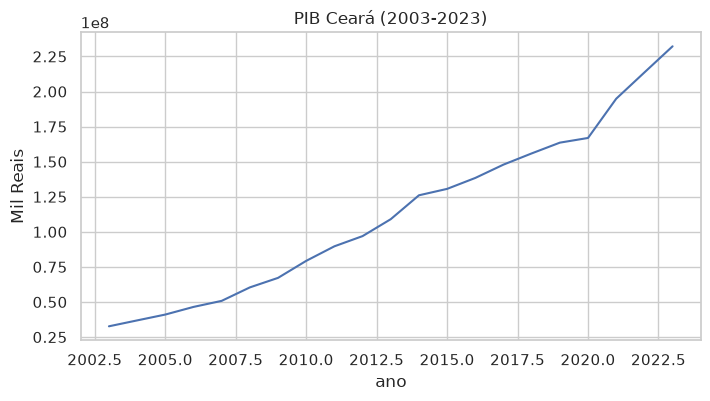

In [20]:
import matplotlib.pyplot as plt

pib_ce = df_ce[df_ce["variavel_nome"] == "Produto Interno Bruto a preços correntes"]

ano_max = pib_ce.loc[pib_ce["valor"].idxmax(), "ano_codigo"]
ano_min = pib_ce.loc[pib_ce["valor"].idxmin(), "ano_codigo"]
print(f"max: {ano_max}, min: {ano_min}")

plt.plot(pib_ce["ano_codigo"], pib_ce["valor"])
plt.title("PIB Ceará (2003-2023)")
plt.xlabel("ano")
plt.ylabel("Mil Reais")
plt.show()

**2. VAB total vs VAB agropecuária, Ceará (2003-2021)**

2022-2023 excluídos aqui (VAB derivado não disponível ainda, ver nota de tratamento de símbolo especial).

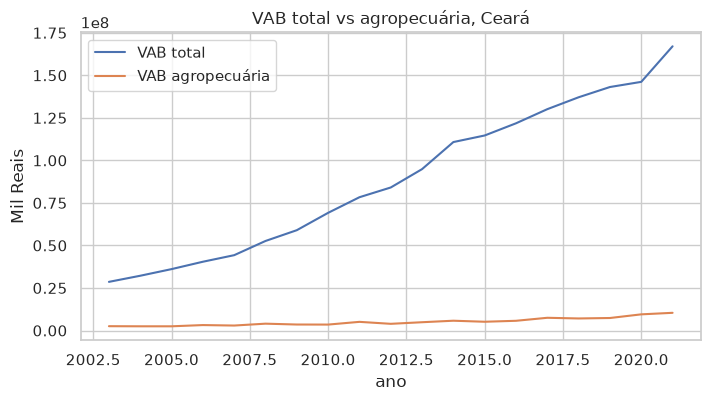

In [21]:
vab_total = df_ce[df_ce["variavel_nome"] == "Valor adicionado bruto a preços correntes total"].dropna(subset=["valor"])
vab_agro = df_ce[df_ce["variavel_nome"] == "Valor adicionado bruto a preços correntes da agropecuária"].dropna(subset=["valor"])

plt.plot(vab_total["ano_codigo"], vab_total["valor"], label="VAB total")
plt.plot(vab_agro["ano_codigo"], vab_agro["valor"], label="VAB agropecuária")
plt.title("VAB total vs agropecuária, Ceará")
plt.xlabel("ano")
plt.ylabel("Mil Reais")
plt.legend()
plt.show()

**3. Participação % da agropecuária no VAB, Ceará**

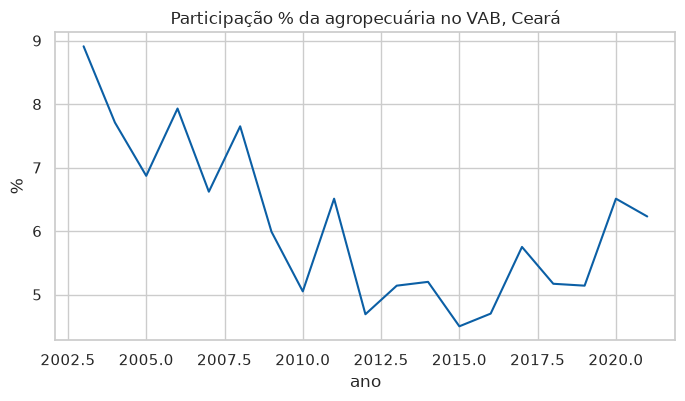

In [22]:
participacao_ce = df_ce[df_ce["variavel_nome"].str.startswith("Participação")].dropna(subset=["valor"])

plt.plot(participacao_ce["ano_codigo"], participacao_ce["valor"], color=AZUL)
plt.title("Participação % da agropecuária no VAB, Ceará")
plt.xlabel("ano")
plt.ylabel("%")
plt.show()

**4. Top 10 municípios por VAB agropecuária (2021, último ano com dado completo)**

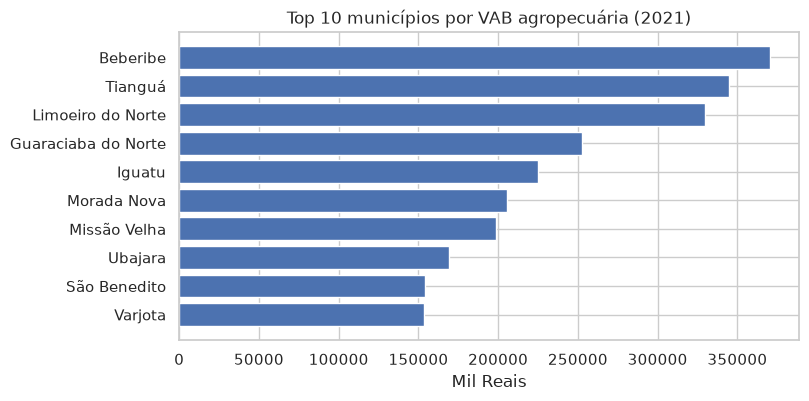

In [23]:
vab_agro_mun_2021 = df_mun[
    (df_mun["variavel_nome"] == "Valor adicionado bruto a preços correntes da agropecuária") &
    (df_mun["ano_codigo"] == 2021)
].sort_values("valor", ascending=False).head(10)

plt.barh(vab_agro_mun_2021["territorio_nome"], vab_agro_mun_2021["valor"])
plt.title("Top 10 municípios por VAB agropecuária (2021)")
plt.xlabel("Mil Reais")
plt.gca().invert_yaxis()
plt.show()

**5. Distribuição da participação % agro entre municípios (2021)**

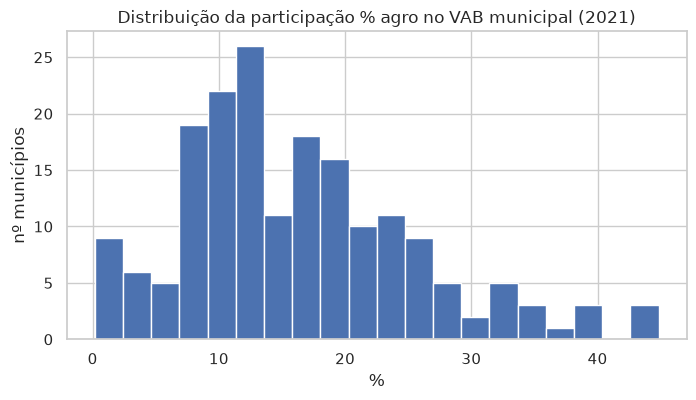

In [24]:
participacao_mun_2021 = df_mun[
    (df_mun["variavel_nome"].str.startswith("Participação")) &
    (df_mun["ano_codigo"] == 2021)
]["valor"]

plt.hist(participacao_mun_2021, bins=20)
plt.title("Distribuição da participação % agro no VAB municipal (2021)")
plt.xlabel("%")
plt.ylabel("nº municípios")
plt.show()

**6. Tamanho do município (VAB total) vs peso da agropecuária (%), 2021**

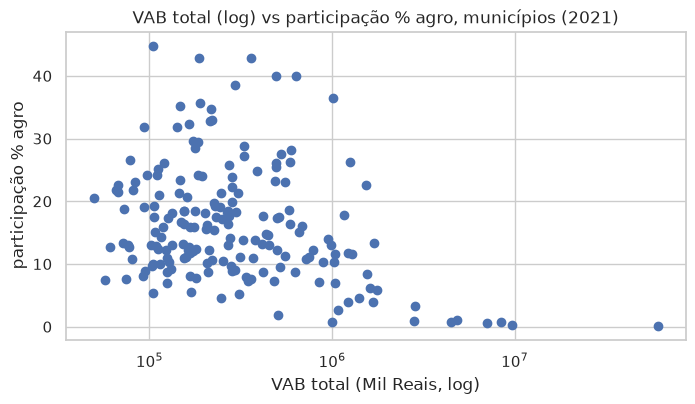

In [25]:
mun_2021_wide = df_mun[df_mun["ano_codigo"] == 2021].pivot_table(
    index="territorio_nome", columns="variavel_nome", values="valor"
)

col_total = "Valor adicionado bruto a preços correntes total"
col_part = [c for c in mun_2021_wide.columns if c.startswith("Participação")][0]

plt.scatter(mun_2021_wide[col_total], mun_2021_wide[col_part])
plt.xscale("log")
plt.title("VAB total (log) vs participação % agro, municípios (2021)")
plt.xlabel("VAB total (Mil Reais, log)")
plt.ylabel("participação % agro")
plt.show()

**7. Taxa de crescimento anual (%) do PIB, Ceará**

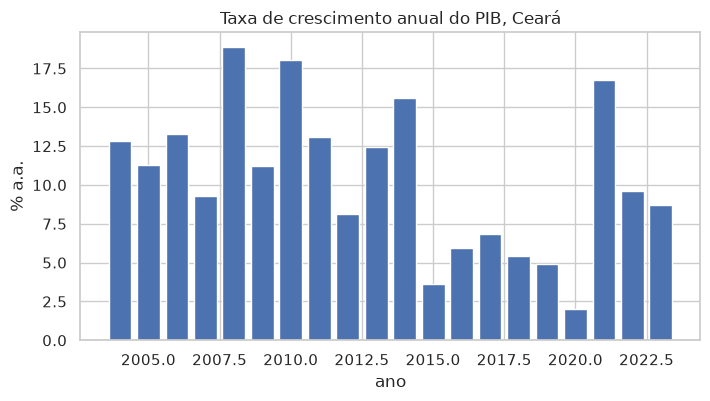

In [26]:
crescimento_ce = pib_ce["valor"].pct_change() * 100

plt.bar(pib_ce["ano_codigo"], crescimento_ce)
plt.title("Taxa de crescimento anual do PIB, Ceará")
plt.xlabel("ano")
plt.ylabel("% a.a.")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

**8. Top 10 municípios que mais cresceram em VAB agropecuária (2003 vs 2021)**

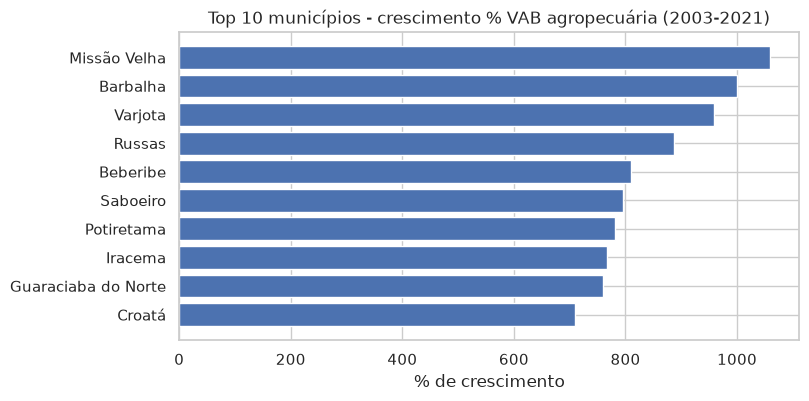

In [27]:
vab_agro_mun = df_mun[df_mun["variavel_nome"] == "Valor adicionado bruto a preços correntes da agropecuária"]
vab_agro_wide = vab_agro_mun.pivot_table(index="territorio_nome", columns="ano_codigo", values="valor")

crescimento_mun = ((vab_agro_wide[2021] / vab_agro_wide[2003]) - 1) * 100
top10_crescimento = crescimento_mun.sort_values(ascending=False).head(10)

plt.barh(top10_crescimento.index, top10_crescimento.values)
plt.title("Top 10 municípios - crescimento % VAB agropecuária (2003-2021)")
plt.xlabel("% de crescimento")
plt.gca().invert_yaxis()
plt.show()

**9. Transformação da estrutura econômica — mudança na participação % agro por município (2003 vs 2021)**

Diferente do item 8 (que olha o VAB agro em valor absoluto), aqui é a **participação %** — ou seja, se a agropecuária ganhou ou perdeu peso relativo na economia do município, não só se cresceu em Mil Reais (a economia toda pode ter crescido mais rápido que a agropecuária, por exemplo).

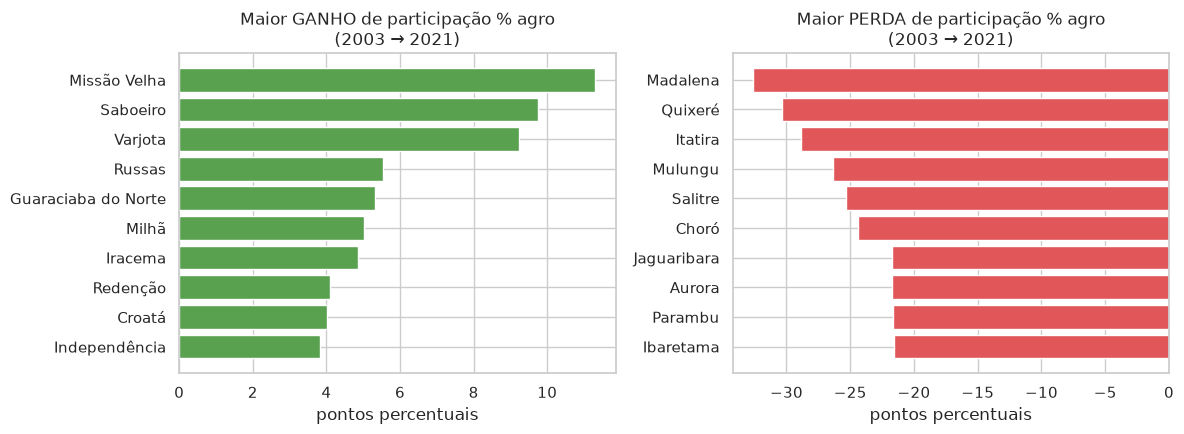

In [28]:
participacao_mun = df_mun[df_mun["variavel_nome"].str.startswith("Participação")]
participacao_wide = participacao_mun.pivot_table(index="territorio_nome", columns="ano_codigo", values="valor")

mudanca_participacao = (participacao_wide[2021] - participacao_wide[2003]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

top10_ganho = mudanca_participacao.head(10)
axes[0].barh(top10_ganho.index, top10_ganho.values, color="#59A14F")
axes[0].set_title("Maior GANHO de participação % agro\n(2003 → 2021)")
axes[0].set_xlabel("pontos percentuais")
axes[0].invert_yaxis()

top10_perda = mudanca_participacao.tail(10).sort_values()
axes[1].barh(top10_perda.index, top10_perda.values, color="#E15759")
axes[1].set_title("Maior PERDA de participação % agro\n(2003 → 2021)")
axes[1].set_xlabel("pontos percentuais")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Qualidade dos dados, forma da distribuição e estatística

**10. Outliers — VAB agropecuária municipal (2021), boxplot + regra IQR**

/tmp/ipykernel_96566/1276787347.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(vab_agro_2021["valor"], vert=False)


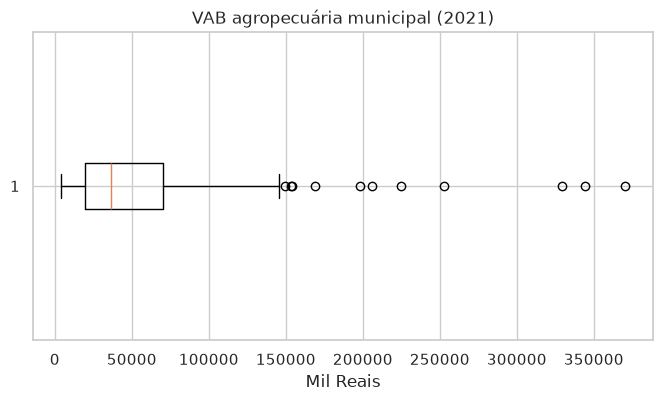

,territorio_nome,valor
8439,Beberibe,370244.0
11505,Tianguá,344455.0
9993,Limoeiro do Norte,329454.0
9279,Guaraciaba do Norte,252867.0
9468,Iguatu,225091.0
10308,Morada Nova,205851.0
10245,Missão Velha,198476.0
11568,Ubajara,169107.0
11232,São Benedito,154035.0
11673,Varjota,153292.0


In [29]:
vab_agro_2021 = df_mun[
    (df_mun["variavel_nome"] == "Valor adicionado bruto a preços correntes da agropecuária") &
    (df_mun["ano_codigo"] == 2021)
]

plt.boxplot(vab_agro_2021["valor"], vert=False)
plt.title("VAB agropecuária municipal (2021)")
plt.xlabel("Mil Reais")
plt.show()

q1, q3 = vab_agro_2021["valor"].quantile([0.25, 0.75])
iqr = q3 - q1
limite = q3 + 1.5 * iqr

outliers = vab_agro_2021[vab_agro_2021["valor"] > limite].sort_values("valor", ascending=False)
outliers[["territorio_nome", "valor"]]

**11. Estatística descritiva (quartis, média, desvio) — VAB agropecuária municipal (2021)**

In [30]:
vab_agro_2021["valor"].describe()

count       184.000000
mean      56578.032609
std       58594.297615
min        4262.000000
25%       19711.250000
50%       36606.500000
75%       70268.250000
max      370244.000000
Name: valor, dtype: float64

In [31]:
vab_agro_2021["valor"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.10     11373.40
0.25     19711.25
0.50     36606.50
0.75     70268.25
0.90    124569.30
0.95    152713.60
0.99    332004.17
Name: valor, dtype: float64

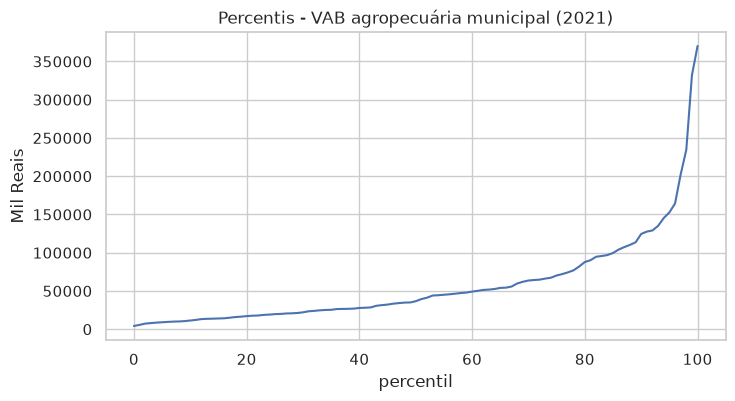

In [32]:
percentis = np.arange(0, 101)
valores_percentis = vab_agro_2021["valor"].quantile(percentis / 100)

plt.plot(percentis, valores_percentis)
plt.title("Percentis - VAB agropecuária municipal (2021)")
plt.xlabel("percentil")
plt.ylabel("Mil Reais")
plt.show()

**12. Concentração — quanto os top 10 municípios respondem do VAB agropecuária total (2021)**

In [33]:
total_vab_agro_2021 = vab_agro_2021["valor"].sum()
top10_vab_agro_2021 = vab_agro_2021.sort_values("valor", ascending=False).head(10)["valor"].sum()

top10_vab_agro_2021 / total_vab_agro_2021 * 100

np.float64(23.081550125365524)

**13. Moda e média aparada — VAB agropecuária municipal (2021)**

Média aparada (`trim_mean`) remove 10% de cada cauda antes de calcular a média — reduz a influência dos municípios extremos. Moda é pouco informativa aqui: `valor` é contínuo (Mil Reais), dificilmente dois municípios têm exatamente o mesmo VAB — calculamos mesmo assim pra completar o quadro de medidas de centralidade.

In [34]:
medidas_centralidade = pd.DataFrame({
    "Medida": ["Média", "Mediana", "Moda", "Média aparada (10% em cada cauda)"],
    "VAB agropecuária (Mil Reais)": [
        vab_agro_2021["valor"].mean(),
        vab_agro_2021["valor"].median(),
        vab_agro_2021["valor"].mode().iloc[0],
        stats.trim_mean(vab_agro_2021["valor"], 0.10),
    ],
})

medidas_centralidade.round(2)

,Medida,VAB agropecuária (Mil Reais)
0,Média,56578.03
1,Mediana,36606.50
2,Moda,4262.00
3,Média aparada (10% em cada cauda),45737.85


**14. Intervalo interquartil (IIQ) — VAB agropecuária municipal (2021)**

IIQ = Q3 - Q1, mede a largura da metade central da distribuição (já calculamos Q1/Q3 no item 11, aqui só nomeia a métrica).

In [35]:
q1, q3 = vab_agro_2021["valor"].quantile([0.25, 0.75])
iiq = q3 - q1
iiq

50557.0

**15. Média simples vs. média ponderada — participação % agro entre municípios (2021)**

Média simples trata cada município igual, não importa o tamanho. Média ponderada pelo VAB total pesa mais os municípios maiores — por isso fica mais perto do valor calculado direto pro Ceará como um todo (que não é a média dos municípios, é o agregado estadual).

In [36]:
media_simples = mun_2021_wide[col_part].mean()
media_ponderada = np.average(mun_2021_wide[col_part], weights=mun_2021_wide[col_total])
valor_ceara = participacao_ce.loc[participacao_ce["ano_codigo"] == 2021, "valor"].iloc[0]

comparacao_medias = pd.DataFrame({
    "Cálculo": [
        "Média simples entre municípios",
        "Média entre municípios ponderada pelo VAB total",
        "Valor agregado do Ceará (direto na tabela)",
    ],
    "Participação % agro": [media_simples, media_ponderada, valor_ceara],
})

comparacao_medias.round(2)

,Cálculo,Participação % agro
0,Média simples entre municípios,16.23
1,Média entre municípios ponderada pelo VAB total,6.23
2,Valor agregado do Ceará (direto na tabela),6.23


**16. Assimetria — VAB agropecuária municipal (2021)**

Assimetria positiva = cauda longa à direita (muitos municípios pequenos, poucos grandes puxando a cauda).

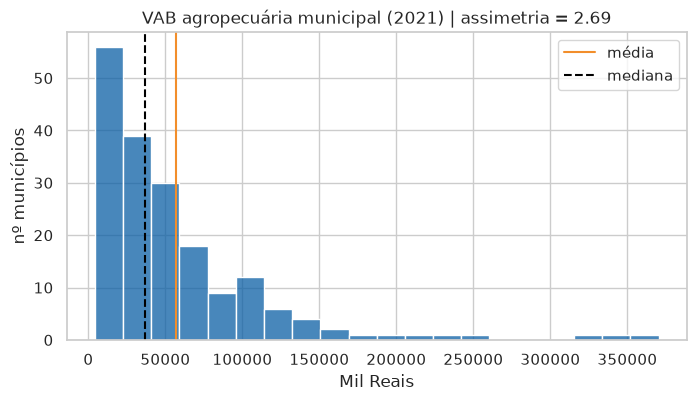

In [37]:
ax = sns.histplot(vab_agro_2021["valor"], color=AZUL, bins=20)
ax.axvline(vab_agro_2021["valor"].mean(), color=LARANJA, label="média")
ax.axvline(vab_agro_2021["valor"].median(), color="black", linestyle="--", label="mediana")
ax.set(
    title=f"VAB agropecuária municipal (2021) | assimetria = {vab_agro_2021['valor'].skew():.2f}",
    xlabel="Mil Reais", ylabel="nº municípios",
)
ax.legend()
plt.show()

**17. ECDF — VAB agropecuária municipal (2021)**

Função de distribuição acumulada empírica: proporção de municípios com VAB agro até um certo valor. É outra forma de ver os percentis que já calculamos, sem escolher faixas de histograma.

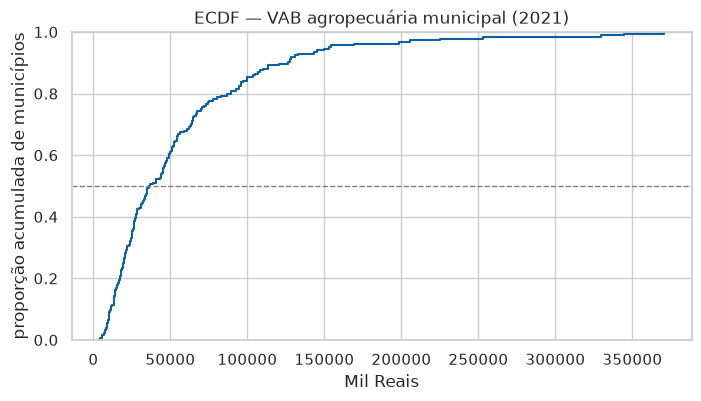

In [38]:
sns.ecdfplot(vab_agro_2021["valor"], color=AZUL)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.title("ECDF — VAB agropecuária municipal (2021)")
plt.xlabel("Mil Reais")
plt.ylabel("proporção acumulada de municípios")
plt.show()

**18. CCDF em escala log-log — concentração do VAB agropecuária (2021)**

Proporção de municípios com VAB agro maior ou igual a cada valor, em escala log-log. Um trecho aproximadamente reto sugere cauda pesada (tipo Pareto) — poucos municípios concentram muito. É só indício visual, não prova de lei de potência.

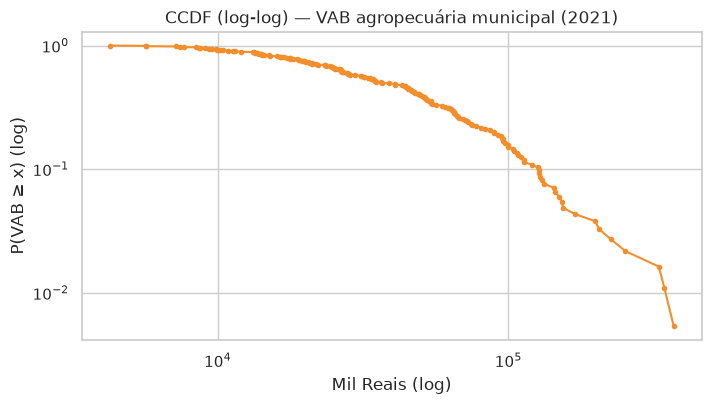

In [39]:
valores_ordenados = np.sort(vab_agro_2021["valor"].unique())
ccdf = [(vab_agro_2021["valor"] >= v).mean() for v in valores_ordenados]

plt.loglog(valores_ordenados, ccdf, "o-", color=LARANJA, markersize=3)
plt.title("CCDF (log-log) — VAB agropecuária municipal (2021)")
plt.xlabel("Mil Reais (log)")
plt.ylabel("P(VAB ≥ x) (log)")
plt.show()

**19. Outliers por z-score (|z| > 3) — comparar com a regra IIQ do item 10**

IIQ é robusto (usa quartis); z-score usa média e desvio-padrão, mais sensível quando a distribuição já é assimétrica (como aqui). Métodos diferentes podem sinalizar municípios diferentes.

In [40]:
z_scores = stats.zscore(vab_agro_2021["valor"])
outliers_z = vab_agro_2021[np.abs(z_scores) > 3].sort_values("valor", ascending=False)

len(outliers_z)
outliers_z[["territorio_nome", "valor"]]

,territorio_nome,valor
8439,Beberibe,370244.0
11505,Tianguá,344455.0
9993,Limoeiro do Norte,329454.0
9279,Guaraciaba do Norte,252867.0


**20. Normalização — MinMax vs Standard vs Robust (VAB agropecuária municipal, 2021)**

Muda a escala, não muda a forma nem a ordem dos municípios. `Robust` usa mediana/IIQ em vez de média/desvio — menos puxado pelos outliers que já identificamos.

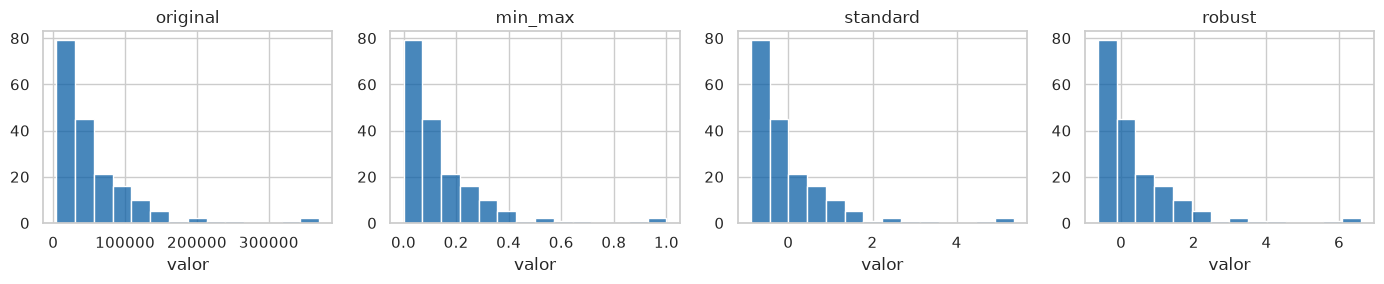

In [41]:
valor = vab_agro_2021["valor"]

escalas = pd.DataFrame({
    "original": valor,
    "min_max": (valor - valor.min()) / (valor.max() - valor.min()),
    "standard": (valor - valor.mean()) / valor.std(),
    "robust": (valor - valor.median()) / iiq,
})

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for coluna, ax in zip(escalas.columns, axes):
    sns.histplot(escalas[coluna], bins=14, color=AZUL, ax=ax)
    ax.set(title=coluna, xlabel="valor", ylabel="")
plt.tight_layout()
plt.show()

**21. Correlação entre as variáveis do PIB municipal (Pearson + Spearman), 2021**

Pearson mede associação linear; Spearman mede associação monotônica (não precisa ser linear). Diferença grande entre os dois é sinal de relação não-linear.

In [42]:
nomes_curtos = {
    "Produto Interno Bruto a preços correntes": "PIB",
    "Valor adicionado bruto a preços correntes total": "VAB total",
    "Valor adicionado bruto a preços correntes da agropecuária": "VAB agro",
    col_part: "Participação % agro",
}
mun_2021_curto = mun_2021_wide.rename(columns=nomes_curtos)

pearson_vs_spearman = pd.DataFrame({
    "Pearson": [mun_2021_curto["VAB total"].corr(mun_2021_curto["Participação % agro"], method="pearson")],
    "Spearman": [mun_2021_curto["VAB total"].corr(mun_2021_curto["Participação % agro"], method="spearman")],
}, index=["VAB total x Participação % agro"])

pearson_vs_spearman.round(3)

,Pearson,Spearman
VAB total x Participação % agro,-0.215,-0.253


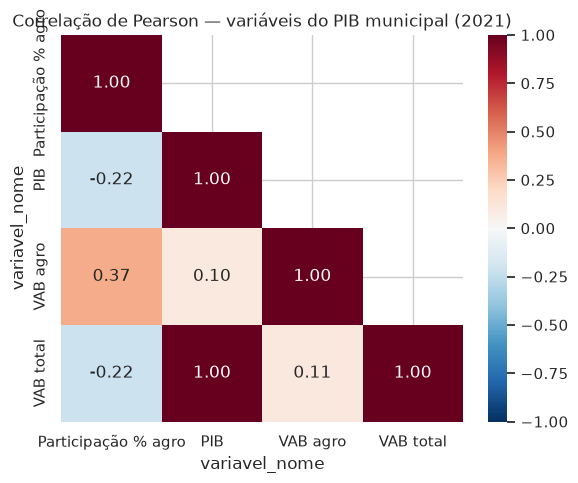

In [43]:
corr = mun_2021_curto.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação de Pearson — variáveis do PIB municipal (2021)")
plt.tight_layout()
plt.show()

**22. Pairplot — todas as variáveis do PIB municipal, 2021**

Visão conjunta: forma de cada distribuição na diagonal, relação par a par fora dela.

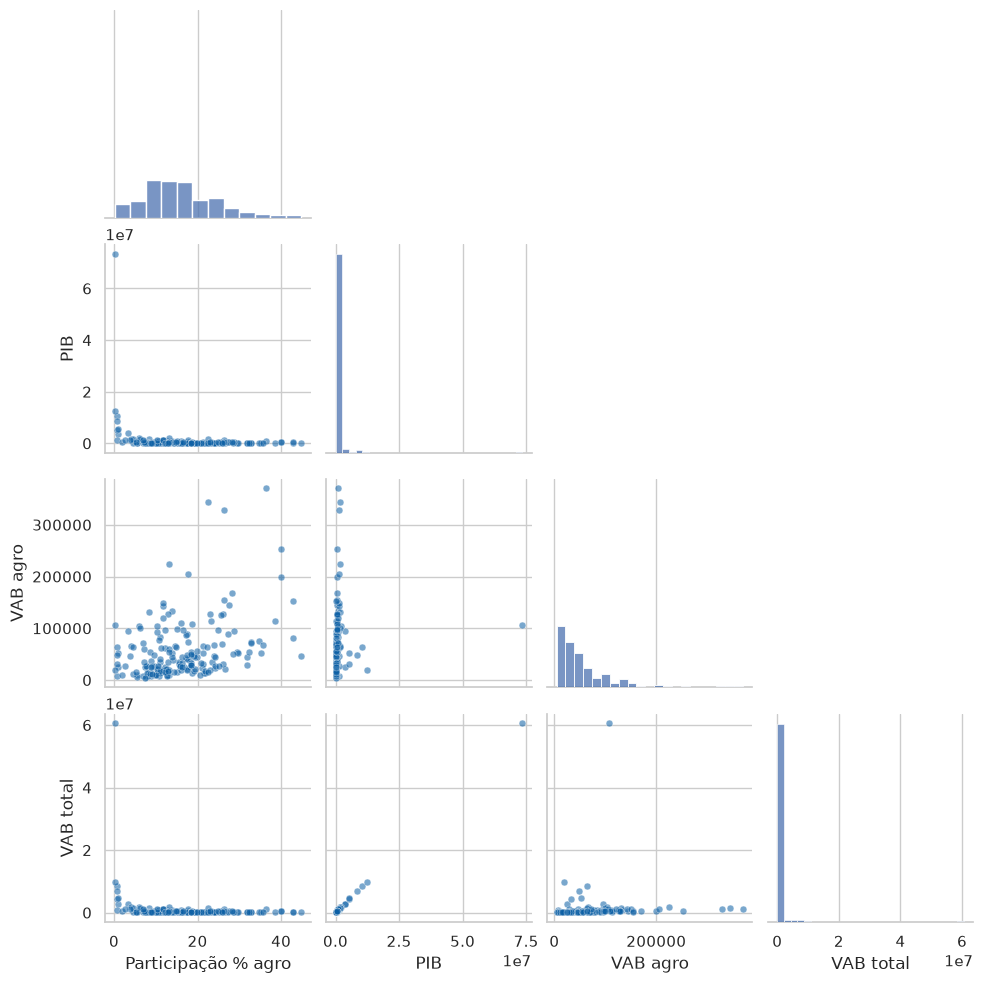

In [44]:
sns.pairplot(mun_2021_curto, corner=True, diag_kind="hist", plot_kws={"alpha": 0.55, "s": 24, "color": AZUL})
plt.show()

## Resumo

| Técnica | Onde usamos | Cuidado |
|---|---|---|
| Média, mediana, moda, média aparada | Item 11, 13 | Moda pouco útil em dado contínuo |
| Média ponderada | Item 15 | Peso importa quando municípios têm tamanhos muito diferentes |
| Quartis, percentis, IIQ | Item 11, 14 | Método de interpolação pode mudar o resultado |
| Boxplot + regra IIQ | Item 10 | Sinaliza, não decide sozinho se é erro |
| z-score | Item 19 | Sensível quando a distribuição já é assimétrica |
| Assimetria (`skew`) | Item 16 | Não substitui olhar o histograma |
| ECDF | Item 17 | Outra forma de ver os percentis |
| CCDF log-log | Item 18 | Reta no gráfico é indício, não prova de Pareto |
| Normalização (MinMax/Standard/Robust) | Item 20 | Muda escala, não muda outliers nem forma |
| Pearson vs Spearman | Item 21 | Divergência = relação não-linear |
| Heatmap / Pairplot | Item 21, 22 | Correlação não é causalidade |
| Binomial / Poisson | não aplicadas | PIB não tem variável "contagem de sucessos em n tentativas" (as 4 variáveis são contínuas e sempre presentes) — diferente do PAM (produtos) e PPM (rebanhos), que têm teto natural |
| Exponencial | não aplicada | Modela tempo contínuo entre eventos; nosso dado é anual agregado |

## 6. Salvar em `processed`

Aqui salva o `df` já limpo (símbolo especial tratado, nome sem sufixo, coluna redundante removida) num arquivo `.parquet` em `dados/processed/`. Isso é diferente do `raw` (nunca mexe) — é o resultado da limpeza, pronto pra reusar sem rodar a limpeza de novo toda vez.

Parquet em vez de CSV: mantém o tipo da coluna (não perde `int`/`float` na hora de ler de novo) e é mais rápido/leve.

In [45]:
df.to_parquet("../dados/processed/pib_agropecuaria.parquet", index=False)